In [3]:
print("работает")

работает


In [4]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)
print("Папка для данных:", RAW.resolve())

Папка для данных: C:\analytics\brain-25-evidence\data\raw


In [5]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)
print("Папка для данных:", RAW.resolve())

Папка для данных: C:\analytics\brain-25-evidence\data\raw


In [6]:
import sys
print("Ядро использует:", sys.executable)
!{sys.executable} -m pip install requests

Ядро использует: c:\Users\TshK\AppData\Local\Python\pythoncore-3.14-64\python.exe


import matplotlib
print("pandas:", pd.__version__)
print("requests:", requests.__version__)
print("matplotlib:", matplotlib.__version__)
print("✅ все библиотеки на месте")

In [7]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
import matplotlib
print("pandas:", pd.__version__)
print("requests:", requests.__version__)
print("matplotlib:", matplotlib.__version__)
print("✅ все библиотеки на месте")

pandas: 3.0.5
requests: 2.34.2
matplotlib: 3.11.1
✅ все библиотеки на месте


In [9]:
RAW = Path("..") / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)
print("Папка для данных:", RAW.resolve())

Папка для данных: C:\analytics\brain-25-evidence\data\raw


In [10]:
COG = '(cognition OR cognitive OR memory OR attention OR "executive function")'

SUPPLEMENTS = {
    "Креатин": f"creatine AND {COG}",
    "Омега-3": f'("omega-3 fatty acids" OR "fish oil" OR "docosahexaenoic acid" OR "eicosapentaenoic acid") AND {COG}',
    "Витамин D": f'("vitamin D" OR cholecalciferol OR calcidiol) AND {COG}',
    "B12": f'("vitamin B12" OR cobalamin) AND {COG}',
    "Магний": f"magnesium AND {COG}",
    "Кофеин": f"caffeine AND {COG}",
    "L-Теанин": f"theanine AND {COG}",
    "Бакопа": f'("bacopa monnieri" OR bacopa) AND {COG}',
    "Ежовик": f'("hericium erinaceus" OR "lions mane") AND {COG}',
    "Гинкго": f'("ginkgo biloba" OR ginkgo) AND {COG}',
    "Родиола": f'("rhodiola rosea" OR rhodiola) AND {COG}',
    "Ашваганда": f'(ashwagandha OR "withania somnifera") AND {COG}',
    "Фосфатидилсерин": f"phosphatidylserine AND {COG}",
    "Alpha-GPC": f'("alpha-gpc" OR alfoscerate) AND {COG}',
    "CDP-холин": f'(citicoline OR "cdp-choline") AND {COG}',
    "Гуперзин А": f"huperzine AND {COG}",
    "Куркумин": f"(curcumin OR curcuma OR turmeric) AND {COG}",
    "Ресвератрол": f"resveratrol AND {COG}",
    "NAC": f'("n-acetylcysteine" OR acetylcysteine) AND {COG}',
    "Цинк": f"zinc AND {COG}",
    "Тирозин": f"tyrosine AND {COG}",
    "Таурин": f"taurine AND {COG}",
    "CoQ10": f'("coenzyme q10" OR ubiquinone) AND {COG}',
    "Пикногенол": f'(pycnogenol OR "pinus pinaster") AND {COG}',
    "Готу кола": f'("centella asiatica" OR "gotu kola") AND {COG}',
}
print(f"Добавок в анализе: {len(SUPPLEMENTS)}")

Добавок в анализе: 25


In [11]:
URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"

def count(query: str) -> int:
    try:
        r = requests.get(URL, params={"db": "pubmed", "term": query,
                                      "retmax": 0, "retmode": "json"}, timeout=15)
        r.raise_for_status()
        time.sleep(0.35)
        return int(r.json()["esearchresult"]["count"])
    except Exception as e:
        print(f"⚠️ Ошибка запроса: {e}")
        return -1

In [12]:
rows = []
for name, term in SUPPLEMENTS.items():
    total = count(term)
    rct   = count(f"{term} AND randomized controlled trial[pt]")
    meta  = count(f"{term} AND meta-analysis[pt]")
    rows.append([name, total, rct, meta])
    print(f"{name}: всего={total} | RCT={rct} | мета={meta}")

df = pd.DataFrame(rows, columns=["добавка", "всего_публикаций", "rct", "мета_анализы"])
df = df.sort_values("rct", ascending=False).reset_index(drop=True)
df.to_csv(RAW / "pubmed_evidence.csv", index=False, encoding="utf-8-sig")
df

Креатин: всего=2312 | RCT=116 | мета=25
Омега-3: всего=2366 | RCT=295 | мета=52
Витамин D: всего=4071 | RCT=175 | мета=86


KeyboardInterrupt: 

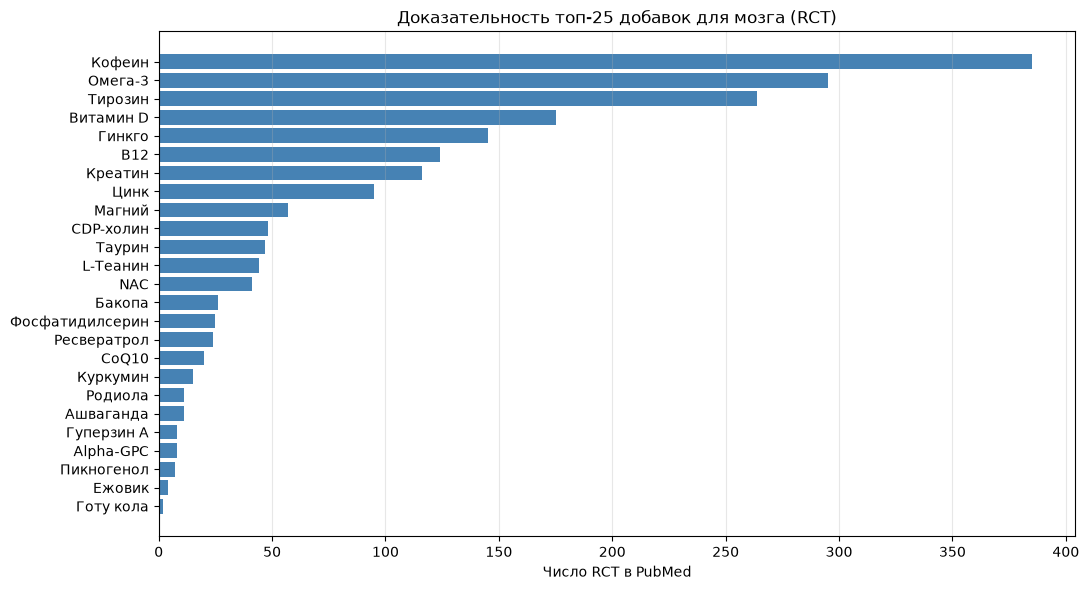

In [ ]:
plt.figure(figsize=(11, 6))
plt.barh(df["добавка"], df["rct"], color="steelblue")
plt.xlabel("Число RCT в PubMed")
plt.title("Доказательность топ-25 добавок для мозга (RCT)")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("../reports/rct_chart.png", dpi=150, bbox_inches="tight")
print("График сохранён в reports/rct_chart.png")

График сохранён в reports/rct_chart.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
print(df.shape)
df.head()

(25, 4)


,добавка,всего_публикаций,rct,мета_анализы
0,Кофеин,2692,385,39
1,Омега-3,2366,295,52
2,Тирозин,9979,264,39
3,Витамин D,4071,175,86
4,Гинкго,1144,145,47


In [ ]:
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
df

,добавка,всего_публикаций,rct,мета_анализы,score
0,Витамин D,4071,175,86,605
1,Кофеин,2692,385,39,580
2,Омега-3,2366,295,52,555
3,Тирозин,9979,264,39,459
4,Гинкго,1144,145,47,380
5,B12,2089,124,50,374
6,Цинк,6559,95,45,320
7,Креатин,2312,116,25,241
8,Магний,2704,57,23,172
9,NAC,729,41,14,111


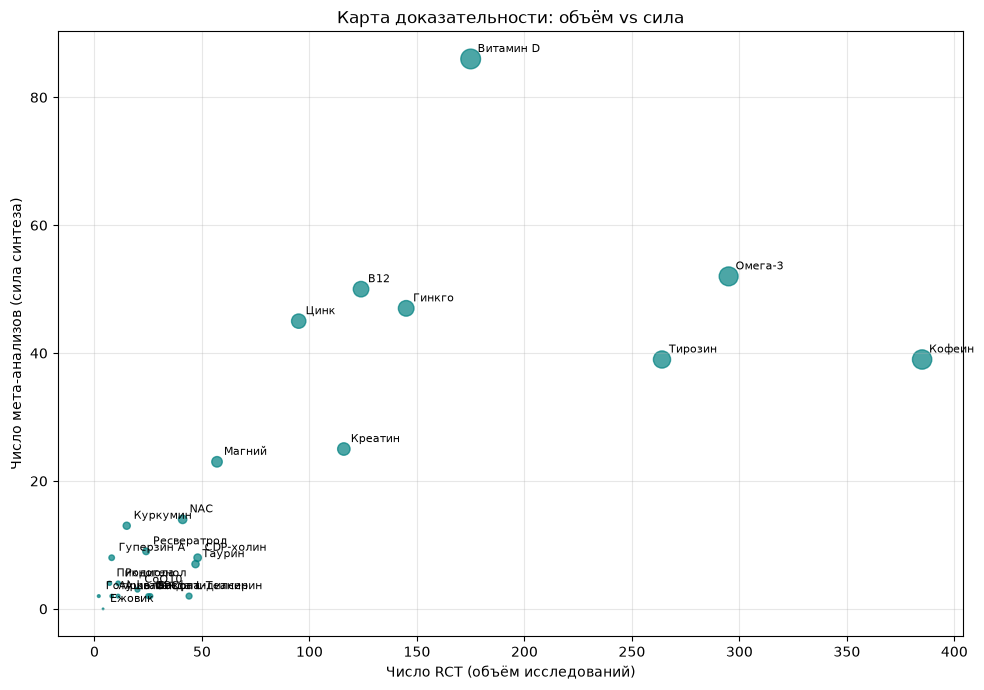

In [13]:
plt.figure(figsize=(10, 7))
plt.scatter(df["rct"], df["мета_анализы"], s=df["score"]/3, alpha=0.7, color="teal")
for _, row in df.iterrows():
    plt.annotate(row["добавка"], (row["rct"], row["мета_анализы"]),
                 fontsize=8, xytext=(5, 5), textcoords="offset points")
plt.xlabel("Число RCT (объём исследований)")
plt.ylabel("Число мета-анализов (сила синтеза)")
plt.title("Карта доказательности: объём vs сила")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
print(df.shape)

(25, 4)


In [ ]:
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
print(df.shape)

(25, 5)


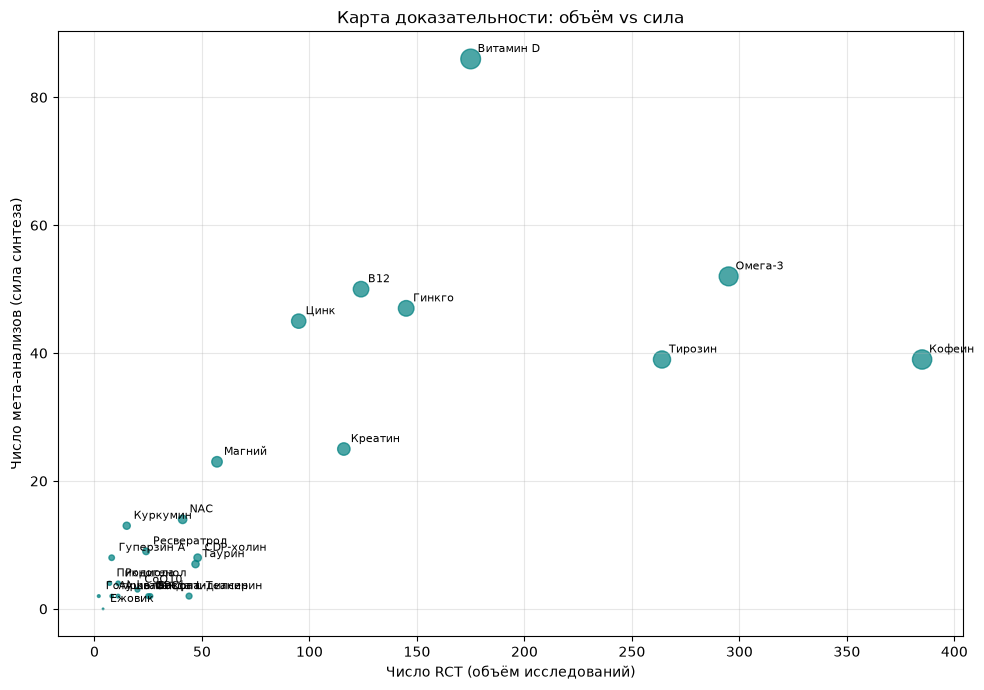

In [14]:
plt.figure(figsize=(10, 7))
plt.scatter(df["rct"], df["мета_анализы"], s=df["score"]/3, alpha=0.7, color="teal")
for _, row in df.iterrows():
    plt.annotate(row["добавка"], (row["rct"], row["мета_анализы"]),
                 fontsize=8, xytext=(5, 5), textcoords="offset points")
plt.xlabel("Число RCT (объём исследований)")
plt.ylabel("Число мета-анализов (сила синтеза)")
plt.title("Карта доказательности: объём vs сила")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
MY_TIER = {
    "Креатин": 1, "Омега-3": 1, "Кофеин": 1, "L-Теанин": 1, "Бакопа": 1,
    "Ашваганда": 1, "Витамин D": 1, "B12": 1, "Цинк": 1,
    "Магний": 2, "Родиола": 2, "Ежовик": 2, "CDP-холин": 2, "Alpha-GPC": 2,
    "Фосфатидилсерин": 2, "Гуперзин А": 2, "NAC": 2, "Тирозин": 2,
    "Гинкго": 3, "Куркумин": 3, "Ресвератрол": 3, "Таурин": 3, "CoQ10": 3,
    "Пикногенол": 3, "Готу кола": 3,
}
df["мой_ярус"] = df["добавка"].map(MY_TIER)
df["ярус_по_данным"] = pd.qcut(df["score"], q=3, labels=[3, 2, 1]).astype(int)
df["расхождение"] = df["мой_ярус"] - df["ярус_по_данным"]

cmp = df[["добавка", "score", "мой_ярус", "ярус_по_данным", "расхождение"]]
cmp.reindex(cmp["расхождение"].abs().sort_values(ascending=False).index)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
print(df.shape)   → ждёшь (25, 5)

SyntaxError: invalid character '→' (U+2192) (624407747.py, line 8)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)

In [3]:
MY_TIER = {
    "Креатин": 1, "Омега-3": 1, "Кофеин": 1, "L-Теанин": 1, "Бакопа": 1,
    "Ашваганда": 1, "Витамин D": 1, "B12": 1, "Цинк": 1,
    "Магний": 2, "Родиола": 2, "Ежовик": 2, "CDP-холин": 2, "Alpha-GPC": 2,
    "Фосфатидилсерин": 2, "Гуперзин А": 2, "NAC": 2, "Тирозин": 2,
    "Гинкго": 3, "Куркумин": 3, "Ресвератрол": 3, "Таурин": 3, "CoQ10": 3,
    "Пикногенол": 3, "Готу кола": 3,
}
df["мой_ярус"] = df["добавка"].map(MY_TIER)
df["ярус_по_данным"] = pd.qcut(df["score"], q=3, labels=[3, 2, 1]).astype(int)
df["расхождение"] = df["мой_ярус"] - df["ярус_по_данным"]

cmp = df[["добавка", "score", "мой_ярус", "ярус_по_данным", "расхождение"]]
cmp.reindex(cmp["расхождение"].abs().sort_values(ascending=False).index)

,добавка,score,мой_ярус,ярус_по_данным,расхождение
4,Гинкго,380,3,1,2
21,Ашваганда,21,1,3,-2
16,Бакопа,36,1,3,-2
3,Тирозин,459,2,1,1
18,Фосфатидилсерин,35,2,3,-1
12,Куркумин,80,3,2,1
13,Ресвератрол,69,3,2,1
22,Alpha-GPC,18,2,3,-1
14,L-Теанин,54,1,2,-1
24,Ежовик,4,2,3,-1


In [ ]:
PROCESSED = Path("..") / "data" / "processed"
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")
plt.savefig("../reports/evidence_scatter.png", dpi=150, bbox_inches="tight")
print("Сохранено: evidence_scored.csv + evidence_scatter.png")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
print(df.shape)

(25, 5)


In [2]:
PROCESSED = Path("..") / "data" / "processed"
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")
print("CSV сохранён:", (PROCESSED / "evidence_scored.csv").resolve())

CSV сохранён: C:\analytics\brain-25-evidence\data\processed\evidence_scored.csv
